In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [2]:
df = pd.read_csv("../data/smartphones_cleaned.csv")
df.sample(5)

,Model,RAM,Storage,Free,Final Price,Smartphone_Freq,is_pro,is_plus,is_max,is_mini,...,Color_Green,Color_Orange,Color_Pink,Color_Purple,Color_Rainbow,Color_Red,Color_Silver,Color_Turquoise,Color_White,Color_Yellow
53,16,8.0,4.859812,1,5.937431,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
520,33,6.0,4.859812,1,6.476972,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1181,54,8.0,4.174387,1,6.536692,1,0,0,0,1,...,True,False,False,False,False,False,False,False,False,False
765,7,8.0,5.549076,1,6.263398,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
945,2,8.0,4.859812,1,5.785639,1,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False


In [3]:
X = df.drop(columns=["Final Price"])
y = df["Final Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=200, random_state=42),
    "MLP": MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42),
     "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    )
}

pipelines = {}

for name in ["Linear Regression", "Ridge", "Lasso"]:
    pipelines[name] = Pipeline([
        ("scaler", StandardScaler()),
        ("model", models[name])
    ])

for name in ["Decision Tree", "Random Forest", "Extra Trees"]:
    pipelines[name] = Pipeline([
        ("model", models[name])
    ])

pipelines["MLP"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", models["MLP"])
])

for name in ["XGBoost", "LightGBM", "CatBoost"]:
    pipelines[name] = Pipeline([
        ("model", models[name])
    ])

In [ ]:
results = []

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append((name, mae, rmse, r2))

    print(name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)
    print("-" * 30)

Linear Regression
MAE: 0.30807011031446435
RMSE: 0.40291714216867375
R2: 0.6584028923254914
------------------------------
Ridge
MAE: 0.3076143473799859
RMSE: 0.401977255707582
R2: 0.6599947234549761
------------------------------
Lasso
MAE: 0.3069706705466776
RMSE: 0.3987850847625821
R2: 0.6653733634341887
------------------------------
Decision Tree
MAE: 0.24780993141238694
RMSE: 0.3836513169075738
R2: 0.6902893914183137
------------------------------
Random Forest
MAE: 0.2078170741463328
RMSE: 0.29560582577975564
R2: 0.8161309328394538
------------------------------


In [ ]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

results_df.sort_values(by="R2", ascending=False)

,Model,MAE,RMSE,R2
4,Random Forest,0.207817,0.295606,0.816131
5,Extra Trees,0.208368,0.302818,0.807049
3,Decision Tree,0.247810,0.383651,0.690289
2,Lasso,0.306971,0.398785,0.665373
1,Ridge,0.307614,0.401977,0.659995
0,Linear Regression,0.308070,0.402917,0.658403
6,MLP,0.304885,0.468544,0.538063


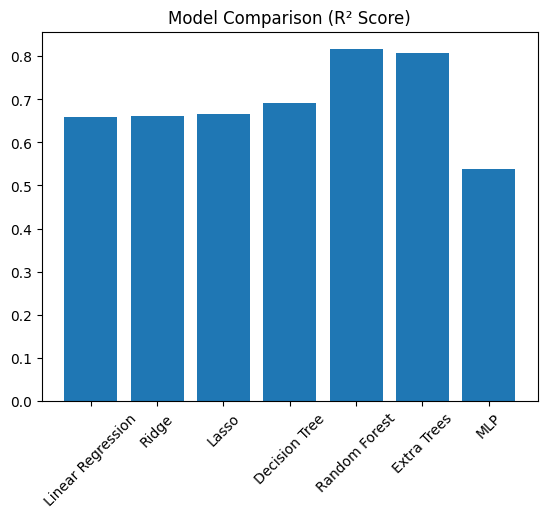

In [ ]:
plt.figure()
plt.bar(results_df["Model"], results_df["R2"])
plt.title("Model Comparison (R² Score)")
plt.xticks(rotation=45)
plt.show()

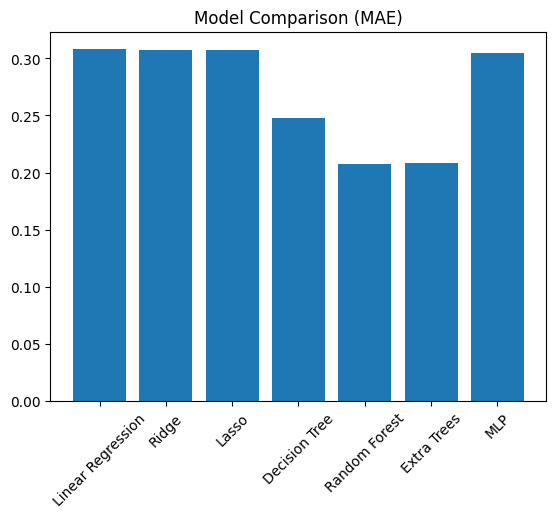

In [ ]:
plt.figure()
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison (MAE)")
plt.xticks(rotation=45)
plt.show()

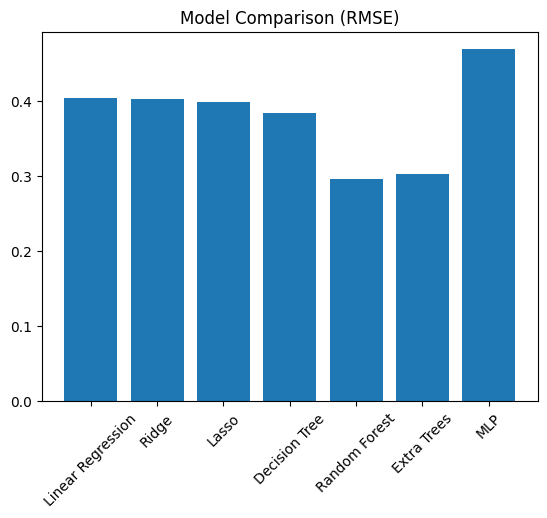

In [ ]:
plt.figure()
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison (RMSE)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
def create_grid(model, param_grid, scale=False):

    steps = []

    if scale:
        steps.append(("scaler", StandardScaler()))

    steps.append(("model", model))

    pipeline = Pipeline(steps)

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    return grid

In [ ]:
ridge_params = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0],
    "model__solver": ["auto", "svd", "cholesky", "lsqr"],
    "model__fit_intercept": [True, False]
}
lasso_params = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
    "model__selection": ["cyclic", "random"],
    "model__max_iter": [1000, 2000, 5000]
}
tree_params = {
    "model__max_depth": [3, 5, 10, 20, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": [None, "sqrt", "log2"],
    "model__criterion": ["squared_error", "friedman_mse"]
}
rf_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
    "model__bootstrap": [True, False]
}
et_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}
mlp_params = {
    "model__hidden_layer_sizes": [
        (64,),
        (128,),
        (128, 64),
        (256, 128)
    ],
    "model__activation": ["relu", "tanh"],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.001, 0.01],
    "model__max_iter": [500, 1000]
}

xgb_params = {
    "model__n_estimators": [200, 300],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

lgbm_params = {
    "model__n_estimators": [200, 300],
    "model__learning_rate": [0.05, 0.1],
    "model__num_leaves": [31, 50, 100],
    "model__max_depth": [-1, 10, 20],
    "model__subsample": [0.8, 1.0]
}

cat_params = {
    "model__iterations": [200, 300],
    "model__learning_rate": [0.05, 0.1],
    "model__depth": [4, 6, 8],
    "model__l2_leaf_reg": [1, 3, 5, 7]
}

models_grid = {
    "Ridge": create_grid(Ridge(), ridge_params, scale=True),
    "Lasso": create_grid(Lasso(), lasso_params, scale=True),
    "Decision Tree": create_grid(DecisionTreeRegressor(random_state=42), tree_params),
    "Random Forest": create_grid(RandomForestRegressor(random_state=42), rf_params),
    "Extra Trees": create_grid(ExtraTreesRegressor(random_state=42), et_params),
    "MLP": create_grid(MLPRegressor(max_iter=500), mlp_params, scale=True),
    "XGBoost": create_grid(
        XGBRegressor(random_state=42, verbosity=0),
        xgb_params
    ),

    "LightGBM": create_grid(
        LGBMRegressor(random_state=42),
        lgbm_params
    ),

    "CatBoost": create_grid(
        CatBoostRegressor(verbose=0, random_state=42),
        cat_params
    )
}

In [ ]:
results_grid = []

for name, grid in models_grid.items():
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)


    mae_grid = mean_absolute_error(y_test, preds)
    rmse_grid = np.sqrt(mean_squared_error(y_test, preds))
    r2_grid = r2_score(y_test, preds)

    results_grid.append((name, mae_grid, rmse_grid, r2_grid))

    print(name)
    print("Best params:", grid.best_params_)
    print("R2:", r2)
    print("-"*30)

Ridge
Best params: {'model__alpha': 100.0, 'model__fit_intercept': True, 'model__solver': 'lsqr'}
R2: 0.5380629995250916
------------------------------
Lasso
Best params: {'model__alpha': 0.001, 'model__max_iter': 1000, 'model__selection': 'random'}
R2: 0.5380629995250916
------------------------------
Decision Tree
Best params: {'model__criterion': 'friedman_mse', 'model__max_depth': 10, 'model__max_features': None, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}
R2: 0.5380629995250916
------------------------------
Random Forest
Best params: {'model__bootstrap': False, 'model__max_depth': 30, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 300}
R2: 0.5380629995250916
------------------------------
Extra Trees
Best params: {'model__max_depth': 20, 'model__max_features': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 300}
R2: 0.5380629995250916
-------------------

KeyboardInterrupt: 

In [ ]:
df_results = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

df_results = df_results.sort_values("R2", ascending=False)
df_results

,Model,MAE,RMSE,R2
4,Random Forest,0.207817,0.295606,0.816131
5,Extra Trees,0.208368,0.302818,0.807049
3,Decision Tree,0.247810,0.383651,0.690289
2,Lasso,0.306971,0.398785,0.665373
1,Ridge,0.307614,0.401977,0.659995
0,Linear Regression,0.308070,0.402917,0.658403
6,MLP,0.304885,0.468544,0.538063


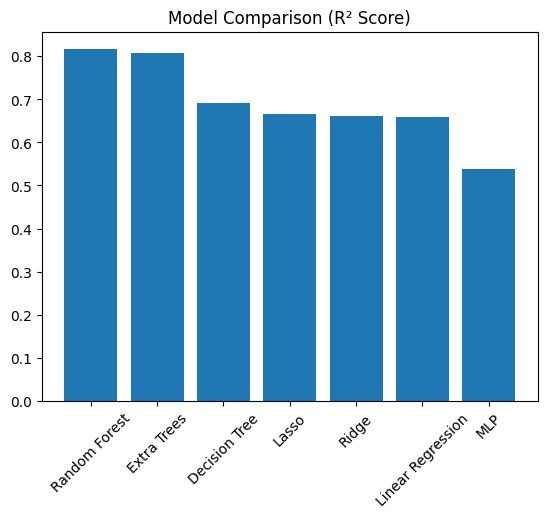

In [ ]:
plt.figure()
plt.bar(df_results["Model"], df_results["R2"])
plt.title("Model Comparison (R² Score)")
plt.xticks(rotation=45)
plt.show()

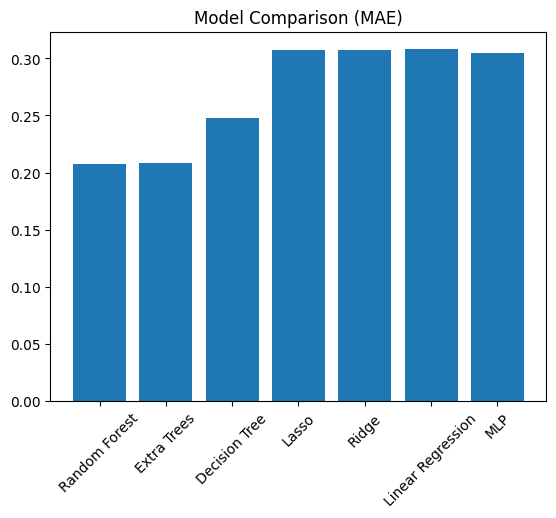

In [ ]:
plt.figure()
plt.bar(df_results["Model"], df_results["MAE"])
plt.title("Model Comparison (MAE)")
plt.xticks(rotation=45)
plt.show()

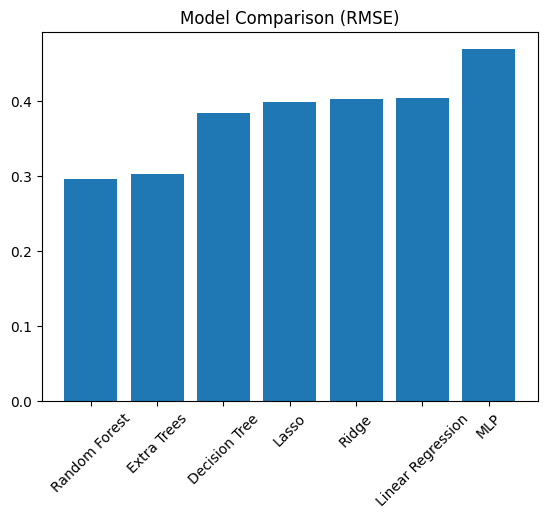

In [ ]:
plt.figure()
plt.bar(df_results["Model"], df_results["RMSE"])
plt.title("Model Comparison (RMSE)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

evaluate_model("XGBoost", y_test, y_pred_xgb)

In [ ]:

lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

evaluate_model("LightGBM", y_test, y_pred_lgbm)

In [ ]:
cat = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

cat.fit(X_train, y_train)

y_pred_cat = cat.predict(X_test)

evaluate_model("CatBoost", y_test, y_pred_cat)